# Installing the required libraries

In [108]:
#%pip install datasets
%pip install transformers
%pip install spacy
%pip install torch
%pip install spacy-transformers
%pip install transformers[torch]
%pip install seqeval

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


...

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Dataset loading:

**Loading dataset and splitting into train, test and validation:**

In [109]:
from datasets import load_dataset, load_metric
dataset = load_dataset("surrey-nlp/PLOD-CW")

In [110]:
train_dataset = dataset["train"]
val_dataset = dataset["validation"]
test_dataset = dataset["test"]

In [111]:
dataset

DatasetDict({
    train: Dataset({
        features: ['tokens', 'pos_tags', 'ner_tags'],
        num_rows: 1072
    })
    validation: Dataset({
        features: ['tokens', 'pos_tags', 'ner_tags'],
        num_rows: 126
    })
    test: Dataset({
        features: ['tokens', 'pos_tags', 'ner_tags'],
        num_rows: 153
    })
})

**Importing the pre-defined BERT tokenizer:**

In [112]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [113]:
tokenized_input = tokenizer(train_dataset["tokens"], is_split_into_words=True)

# Example single sentence example.
for token in tokenized_input["input_ids"]:
    print(tokenizer.convert_ids_to_tokens(token))
    break

Token indices sequence length is longer than the specified maximum sequence length for this model (542 > 512). Running this sequence through the model will result in indexing errors


['[CLS]', 'for', 'this', 'purpose', 'the', 'gothenburg', 'young', 'persons', 'empowerment', 'scale', '(', 'g', '##ype', '##s', ')', 'was', 'developed', '.', '[SEP]']


**Encoding the 'ner_tags':**

In [114]:
label_encoding = {"B-O": 0, "B-AC": 1, "B-LF": 2, "I-LF": 3}

label_list = []
for sample in train_dataset["ner_tags"]:
    label_list.append([label_encoding[tag] for tag in sample])

val_label_list = []
for sample in val_dataset["ner_tags"]:
    val_label_list.append([label_encoding[tag] for tag in sample])

test_label_list = []
for sample in test_dataset["ner_tags"]:
    test_label_list.append([label_encoding[tag] for tag in sample])

**Aligning the tokens and the labels:**

In [115]:
def tokenize_and_align_labels(train_dataset, list_name):
    tokenized_inputs = tokenizer(train_dataset["tokens"], truncation=True, is_split_into_words=True) 

    labels = []
    for i, label in enumerate(list_name):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            # Special tokens have a word id that is None. We set the label to -100 so they are automatically
            # ignored in the loss function.
            if word_idx is None:
                label_ids.append(-100)
            # We set the label for the first token of each word.
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            # For the other tokens in a word, we set the label to either the current label or -100, depending on
            # the label_all_tokens flag.
            else:
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [116]:
tokenized_train_datasets = tokenize_and_align_labels(train_dataset, label_list)
tokenized_val_datasets = tokenize_and_align_labels(val_dataset, val_label_list)
tokenized_test_datasets = tokenize_and_align_labels(test_dataset, test_label_list)

In [117]:
def turn_dict_to_list_of_dict(d):
    new_list = []

    for labels, inputs in zip(d["labels"], d["input_ids"]):
        entry = {"input_ids": inputs, "labels": labels}
        new_list.append(entry)

    return new_list

In [118]:
tokenised_train = turn_dict_to_list_of_dict(tokenized_train_datasets)
tokenised_val = turn_dict_to_list_of_dict(tokenized_val_datasets)
tokenised_test = turn_dict_to_list_of_dict(tokenized_test_datasets)

**Creating the evalutaion metrics:**

In [119]:
import numpy as np

metric = load_metric("seqeval")
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (special tokens)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

/user/HS402/jj01056/.local/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for seqeval contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.0/metrics/seqeval/seqeval.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


# Model Building:

**Base Model:**

In [120]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [121]:
# Define  BI-LSTM model
class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # Multiply by 2 for bidirectional

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        out = self.fc(lstm_out)
        return out

# Convert tokenized data to PyTorch tensors
def convert_to_tensors(tokenized_data):
    input_ids = torch.tensor(tokenized_data['input_ids'])
    labels = torch.tensor(tokenized_data['labels'])
    return input_ids, labels


# Convert tokenized data to PyTorch tensors
train_data = [convert_to_tensors(batch) for batch in tokenised_train]
val_data = [convert_to_tensors(batch) for batch in tokenised_val]
test_data = [convert_to_tensors(batch) for batch in tokenised_test]

# Pad sequences within each batch
def pad_collate(batch):
    (xx, yy) = zip(*batch)
    # Pad input sequences
    xx_pad = torch.nn.utils.rnn.pad_sequence(xx, batch_first=True, padding_value=0)
    # Pad target labels to match the maximum sequence length
    max_seq_len = max(len(seq) for seq in xx)
    yy_pad = torch.nn.utils.rnn.pad_sequence([seq[:max_seq_len] for seq in yy], batch_first=True, padding_value=-100)
    return xx_pad, yy_pad

# Create DataLoader for train, validation, and test sets
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=pad_collate)
val_loader = DataLoader(val_data, batch_size=32, collate_fn=pad_collate)
test_loader = DataLoader(test_data, batch_size=32, collate_fn=pad_collate)

# Define hyperparameters
input_dim = 400000  # Assuming vocabulary size
embedding_dim = 100
hidden_dim = 128
output_dim = 4  # Number of NER classes
num_epochs = 10
learning_rate = 0.001

# Initialize model, loss, and optimizer
model = BiLSTMModel(input_dim, embedding_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss(ignore_index=-100)  # Ignore padding index in loss calculation
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
for epoch in range(num_epochs):
    model.train()
    for input_ids, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1))
        loss.backward()
        optimizer.step()

    # Validate the model
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for input_ids, labels in val_loader:
            outputs = model(input_ids)
            val_loss += criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1)).item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss/len(val_loader):.4f}')

# Test the model
model.eval()
with torch.no_grad():
    test_loss = 0.0
    for input_ids, labels in test_loader:
        outputs = model(input_ids)
        test_loss += criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1)).item()

print(f'Test Loss: {test_loss/len(test_loader):.4f}')


Epoch [1/10], Validation Loss: 0.6155
Epoch [2/10], Validation Loss: 0.5042
Epoch [3/10], Validation Loss: 0.4401
Epoch [4/10], Validation Loss: 0.4205
Epoch [5/10], Validation Loss: 0.4110
Epoch [6/10], Validation Loss: 0.4053
Epoch [7/10], Validation Loss: 0.4034
Epoch [8/10], Validation Loss: 0.4007
Epoch [9/10], Validation Loss: 0.4150
Epoch [10/10], Validation Loss: 0.4547
Test Loss: 0.4086


**Evaluation metrics:**

In [122]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def evaluate_model(model, data_loader, mode='validation'):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels in data_loader:
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=2)
            all_preds.extend(preds.flatten().tolist())
            all_labels.extend(labels.flatten().tolist())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f"{mode.capitalize()} Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print()

    return accuracy, precision, recall, f1

train_accuracy_base, train_precision_base, train_recall_base, train_f1_base = evaluate_model(model, train_loader, mode='train')
val_accuracy_base, val_precision_base, val_recall_base, val_f1_base = evaluate_model(model, val_loader, mode='validation')
test_accuracy_base, test_precision_base, test_recall_base, test_f1_base = evaluate_model(model, test_loader, mode='test')


Train Metrics:
Accuracy: 0.3063
Precision: 0.5247
Recall: 0.6452
F1-score: 0.5364

Validation Metrics:
Accuracy: 0.2509
Precision: 0.3828
Recall: 0.4703
F1-score: 0.3743

Test Metrics:
Accuracy: 0.3504
Precision: 0.3756
Recall: 0.4421
F1-score: 0.3666



**Confusion Matrix:**

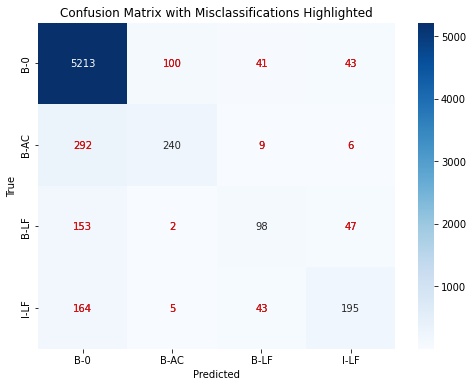

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Evaluate the model
def evaluate_model_confusion_matrix(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels in data_loader:
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=2)

            # Remove tokens with value -100
            mask = labels != -100
            preds = preds[mask]
            labels = labels[mask]

            all_preds.extend(preds.flatten().tolist())
            all_labels.extend(labels.flatten().tolist())

    return all_labels, all_preds


test_labels, test_preds = evaluate_model_confusion_matrix(model, test_loader)


cm = confusion_matrix(test_labels, test_preds)


labels = ['B-0', 'B-AC', 'B-LF', 'I-LF']  

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=labels, yticklabels=labels)


for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            plt.text(j + 0.5, i + 0.5, cm[i, j], color='red', ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix with Misclassifications Highlighted')
plt.show()


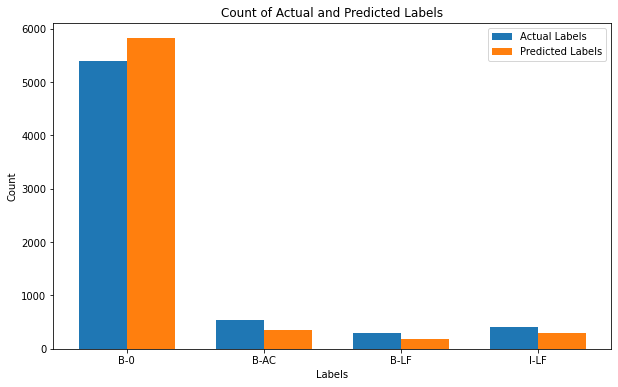

In [124]:
import matplotlib.pyplot as plt


labels = ['B-0', 'B-AC', 'B-LF', 'I-LF']


actual_label_count = {label: test_labels.count(idx) for idx, label in enumerate(labels)}


predicted_label_count = {label: test_preds.count(idx) for idx, label in enumerate(labels)}


fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = np.arange(len(labels))

actual_bars = ax.bar(index, actual_label_count.values(), bar_width, label='Actual Labels')
predicted_bars = ax.bar(index + bar_width, predicted_label_count.values(), bar_width, label='Predicted Labels')

ax.set_xlabel('Labels')
ax.set_ylabel('Count')
ax.set_title('Count of Actual and Predicted Labels')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(labels)
ax.legend()

plt.show()


Mispredicted: B-0 as B-AC - Count: 100
Mispredicted: B-0 as B-LF - Count: 41
Mispredicted: B-0 as I-LF - Count: 43
Mispredicted: B-AC as B-0 - Count: 292
Mispredicted: B-AC as B-LF - Count: 9
Mispredicted: B-AC as I-LF - Count: 6
Mispredicted: B-LF as B-0 - Count: 153
Mispredicted: B-LF as B-AC - Count: 2
Mispredicted: B-LF as I-LF - Count: 47
Mispredicted: I-LF as B-0 - Count: 164
Mispredicted: I-LF as B-AC - Count: 5
Mispredicted: I-LF as B-LF - Count: 43


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

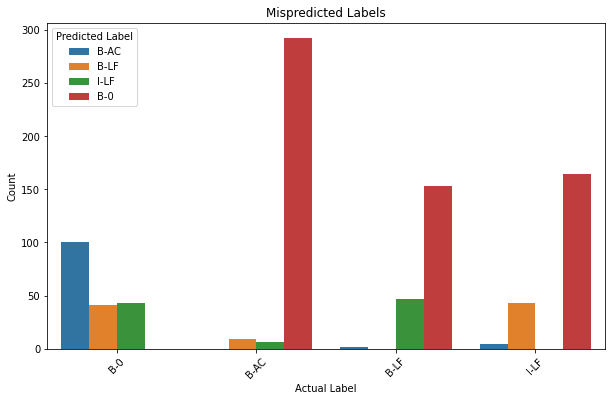

In [125]:
import pandas as pd

def get_mispredicted_pairs(confusion_matrix, labels):
    mispredicted_pairs = []

    for i in range(len(labels)):
        for j in range(len(labels)):
            if i != j and confusion_matrix[i, j] > 0:
                mispredicted_pairs.append((labels[i], labels[j], confusion_matrix[i, j]))

    return mispredicted_pairs

mispredicted_pairs = get_mispredicted_pairs(cm, labels)
for pair in mispredicted_pairs:
    print(f"Mispredicted: {pair[0]} as {pair[1]} - Count: {pair[2]}")



mispredicted_df = pd.DataFrame(mispredicted_pairs, columns=['Actual', 'Predicted', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Actual', y='Count', hue='Predicted', data=mispredicted_df)
plt.title('Mispredicted Labels')
plt.xlabel('Actual Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Predicted Label')
plt.show()


**HP-1:**

In [126]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Define BI-LSTM model
class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # Multiply by 2 for bidirectional

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        out = self.fc(lstm_out)
        return out

# Convert tokenized data to PyTorch tensors
def convert_to_tensors(tokenized_data):
    input_ids = torch.tensor(tokenized_data['input_ids'])
    labels = torch.tensor(tokenized_data['labels'])
    return input_ids, labels

# Convert tokenized data to PyTorch tensors
train_data = [convert_to_tensors(batch) for batch in tokenised_train]
val_data = [convert_to_tensors(batch) for batch in tokenised_val]
test_data = [convert_to_tensors(batch) for batch in tokenised_test]

# Pad sequences within each batch
def pad_collate(batch):
    (xx, yy) = zip(*batch)
    xx_pad = torch.nn.utils.rnn.pad_sequence(xx, batch_first=True, padding_value=0)
    max_seq_len = max(len(seq) for seq in xx)
    yy_pad = torch.nn.utils.rnn.pad_sequence([seq[:max_seq_len] for seq in yy], batch_first=True, padding_value=-100)
    return xx_pad, yy_pad

# Create DataLoader for train, validation, and test sets
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=pad_collate)
val_loader = DataLoader(val_data, batch_size=32, collate_fn=pad_collate)
test_loader = DataLoader(test_data, batch_size=32, collate_fn=pad_collate)

# Define hyperparameters
input_dim = 400000  
embedding_dim = 200  # Increased embedding dimension
hidden_dim = 256  # Increased hidden dimension
output_dim = 4  # Number of NER classes
num_epochs = 15  # Increased number of epochs
learning_rate = 0.0005  # Decreased learning rate

# Initialize model, loss, and optimizer
model = BiLSTMModel(input_dim, embedding_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss(ignore_index=-100)  # Ignore padding index in loss calculation
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


# Train the model
for epoch in range(num_epochs):
    model.train()
    for input_ids, labels in train_loader:
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids)

        # Calculate loss
        loss = criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1))

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

    # Validate the model
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for input_ids, labels in val_loader:
            outputs = model(input_ids)
            val_loss += criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1)).item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss/len(val_loader):.4f}')

# Test the model
model.eval()
with torch.no_grad():
    test_loss = 0.0
    for input_ids, labels in test_loader:
        outputs = model(input_ids)
        test_loss += criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1)).item()

print(f'Test Loss: {test_loss/len(test_loader):.4f}')


Epoch [1/15], Validation Loss: 0.5989
Epoch [2/15], Validation Loss: 0.4726
Epoch [3/15], Validation Loss: 0.4401
Epoch [4/15], Validation Loss: 0.4157
Epoch [5/15], Validation Loss: 0.4040
Epoch [6/15], Validation Loss: 0.3908
Epoch [7/15], Validation Loss: 0.3942
Epoch [8/15], Validation Loss: 0.4080
Epoch [9/15], Validation Loss: 0.4314
Epoch [10/15], Validation Loss: 0.4365
Epoch [11/15], Validation Loss: 0.4577
Epoch [12/15], Validation Loss: 0.4527
Epoch [13/15], Validation Loss: 0.4788
Epoch [14/15], Validation Loss: 0.5071
Epoch [15/15], Validation Loss: 0.5781
Test Loss: 0.5209


**Evaluation Metrics:**

In [127]:
from sklearn.metrics import *
def evaluate_model(model, data_loader, mode='validation'):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels in data_loader:
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=2)
            all_preds.extend(preds.flatten().tolist())
            all_labels.extend(labels.flatten().tolist())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f"{mode.capitalize()} Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print()

    return accuracy, precision, recall, f1, all_preds, all_labels

train_accuracy_tnf, train_precision_tnf, train_recall_tnf, train_f1_tnf, train_preds, train_labels = evaluate_model(model, train_loader, mode='train')
val_accuracy_tnf, val_precision_tnf, val_recall_tnf, val_f1_tnf, val_preds, val_labels = evaluate_model(model, val_loader, mode='validation')
test_accuracy_tnf, test_precision_tnf, test_recall_tnf, test_f1_tnf, test_preds, test_labels = evaluate_model(model, test_loader, mode='test')


print("Test Classification Report:")
print(classification_report(test_labels, test_preds, zero_division=0))


Train Metrics:
Accuracy: 0.3274
Precision: 0.6241
Recall: 0.7577
F1-score: 0.6499

Validation Metrics:
Accuracy: 0.2494
Precision: 0.4232
Recall: 0.4770
F1-score: 0.3998

Test Metrics:
Accuracy: 0.3492
Precision: 0.4114
Recall: 0.4717
F1-score: 0.4088

Test Classification Report:
              precision    recall  f1-score   support

        -100       0.00      0.00      0.00      9748
           0       0.33      0.95      0.49      5397
           1       0.59      0.50      0.54       547
           2       0.52      0.41      0.46       300
           3       0.61      0.50      0.55       407

    accuracy                           0.35     16399
   macro avg       0.41      0.47      0.41     16399
weighted avg       0.15      0.35      0.20     16399



**Confusion Matrix:**

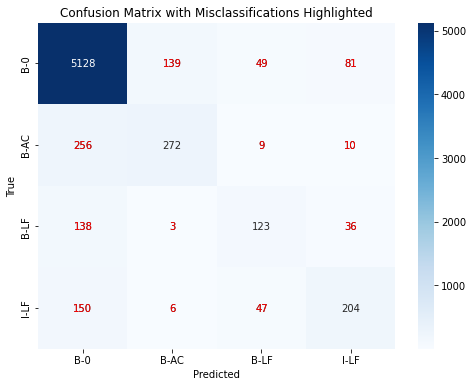

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def evaluate_model_confusion_matrix(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels in data_loader:
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=2)
            mask = labels != -100
            preds = preds[mask]
            labels = labels[mask]
            all_preds.extend(preds.flatten().tolist())
            all_labels.extend(labels.flatten().tolist())

    return all_labels, all_preds

test_labels, test_preds = evaluate_model_confusion_matrix(model, test_loader)

cm = confusion_matrix(test_labels, test_preds)

# Define labels for confusion matrix
labels = ['B-0', 'B-AC', 'B-LF', 'I-LF']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=labels, yticklabels=labels)


for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            plt.text(j + 0.5, i + 0.5, cm[i, j], color='red', ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix with Misclassifications Highlighted')
plt.show()


Mispredicted: B-0 as B-AC - Count: 139
Mispredicted: B-0 as B-LF - Count: 49
Mispredicted: B-0 as I-LF - Count: 81
Mispredicted: B-AC as B-0 - Count: 256
Mispredicted: B-AC as B-LF - Count: 9
Mispredicted: B-AC as I-LF - Count: 10
Mispredicted: B-LF as B-0 - Count: 138
Mispredicted: B-LF as B-AC - Count: 3
Mispredicted: B-LF as I-LF - Count: 36
Mispredicted: I-LF as B-0 - Count: 150
Mispredicted: I-LF as B-AC - Count: 6
Mispredicted: I-LF as B-LF - Count: 47


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

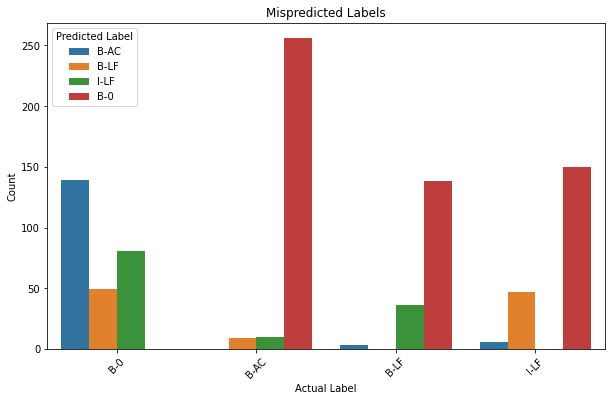

In [129]:
import pandas as pd

def get_mispredicted_pairs(confusion_matrix, labels):
    mispredicted_pairs = []

    for i in range(len(labels)):
        for j in range(len(labels)):
            if i != j and confusion_matrix[i, j] > 0:
                mispredicted_pairs.append((labels[i], labels[j], confusion_matrix[i, j]))

    return mispredicted_pairs

mispredicted_pairs = get_mispredicted_pairs(cm, labels)
for pair in mispredicted_pairs:
    print(f"Mispredicted: {pair[0]} as {pair[1]} - Count: {pair[2]}")


# Convert mispredicted pairs to DataFrame
mispredicted_df = pd.DataFrame(mispredicted_pairs, columns=['Actual', 'Predicted', 'Count'])

# Plot mispredicted pairs
plt.figure(figsize=(10, 6))
sns.barplot(x='Actual', y='Count', hue='Predicted', data=mispredicted_df)
plt.title('Mispredicted Labels')
plt.xlabel('Actual Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Predicted Label')
plt.show()


**HP-2:**

In [130]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Define the BI-LSTM model with dropout
class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, dropout):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        lstm_out = self.dropout(lstm_out)  # Apply dropout
        out = self.fc(lstm_out)
        return out

# Convert tokenized data to PyTorch tensors
def convert_to_tensors(tokenized_data):
    input_ids = torch.tensor(tokenized_data['input_ids'])
    labels = torch.tensor(tokenized_data['labels'])
    return input_ids, labels
train_data = [convert_to_tensors(batch) for batch in tokenised_train]
val_data = [convert_to_tensors(batch) for batch in tokenised_val]
test_data = [convert_to_tensors(batch) for batch in tokenised_test]
# Define padding function
def pad_collate(batch):
    (xx, yy) = zip(*batch)
    xx_pad = torch.nn.utils.rnn.pad_sequence(xx, batch_first=True, padding_value=0)
    max_seq_len = max(len(seq) for seq in xx)
    yy_pad = torch.nn.utils.rnn.pad_sequence([seq[:max_seq_len] for seq in yy], batch_first=True, padding_value=-100)
    return xx_pad, yy_pad

# Create DataLoader for train, validation, and test sets
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=pad_collate)
val_loader = DataLoader(val_data, batch_size=32, collate_fn=pad_collate)
test_loader = DataLoader(test_data, batch_size=32, collate_fn=pad_collate)

# Define model parameters
input_dim = 400000
embedding_dim = 100
hidden_dim = 128
output_dim = 4
dropout = 0.5  # Dropout probability
num_epochs = 10
learning_rate = 0.001

# Initialize model, loss, and optimizer
model = BiLSTMModel(input_dim, embedding_dim, hidden_dim, output_dim, dropout)
criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)

# Training and validating the model
for epoch in range(num_epochs):
    model.train()
    for input_ids, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1))
        loss.backward()
        optimizer.step()
    
    # Model validation
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for input_ids, labels in val_loader:
            outputs = model(input_ids)
            val_loss += criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1)).item()
    
    scheduler.step(val_loss) 
    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss/len(val_loader):.4f}')

# Testing the model
model.eval()
with torch.no_grad():
    test_loss = 0.0
    for input_ids, labels in test_loader:
        outputs = model(input_ids)
        test_loss += criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1)).item()

print(f'Test Loss: {test_loss/len(test_loader):.4f}')


/user/HS402/jj01056/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch [1/10], Validation Loss: 0.6243
Epoch [2/10], Validation Loss: 0.4976
Epoch [3/10], Validation Loss: 0.4589
Epoch [4/10], Validation Loss: 0.4298
Epoch [5/10], Validation Loss: 0.4142
Epoch [6/10], Validation Loss: 0.4161
Epoch [7/10], Validation Loss: 0.4032
Epoch [8/10], Validation Loss: 0.4079
Epoch [9/10], Validation Loss: 0.4241
Epoch [10/10], Validation Loss: 0.4388
Test Loss: 0.4246


In [131]:
from sklearn.metrics import *
def evaluate_model(model, data_loader, mode='validation'):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels in data_loader:
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=2)
            all_preds.extend(preds.flatten().tolist())
            all_labels.extend(labels.flatten().tolist())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f"{mode.capitalize()} Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print()

    return accuracy, precision, recall, f1, all_preds, all_labels

train_accuracy_tnf, train_precision_tnf, train_recall_tnf, train_f1_tnf, train_preds, train_labels = evaluate_model(model, train_loader, mode='train')
val_accuracy_tnf, val_precision_tnf, val_recall_tnf, val_f1_tnf, val_preds, val_labels = evaluate_model(model, val_loader, mode='validation')
test_accuracy_tnf, test_precision_tnf, test_recall_tnf, test_f1_tnf, test_preds, test_labels = evaluate_model(model, test_loader, mode='test')


print("Test Classification Report:")
print(classification_report(test_labels, test_preds, zero_division=0))


Train Metrics:
Accuracy: 0.3038
Precision: 0.5533
Recall: 0.6526
F1-score: 0.5585

Validation Metrics:
Accuracy: 0.2480
Precision: 0.4078
Recall: 0.4818
F1-score: 0.3948

Test Metrics:
Accuracy: 0.3471
Precision: 0.4010
Recall: 0.4779
F1-score: 0.4064

Test Classification Report:
              precision    recall  f1-score   support

        -100       0.00      0.00      0.00      9748
           0       0.33      0.94      0.49      5397
           1       0.60      0.49      0.54       547
           2       0.50      0.35      0.41       300
           3       0.57      0.61      0.59       407

    accuracy                           0.35     16399
   macro avg       0.40      0.48      0.41     16399
weighted avg       0.15      0.35      0.20     16399



**Confusion Matrix:**

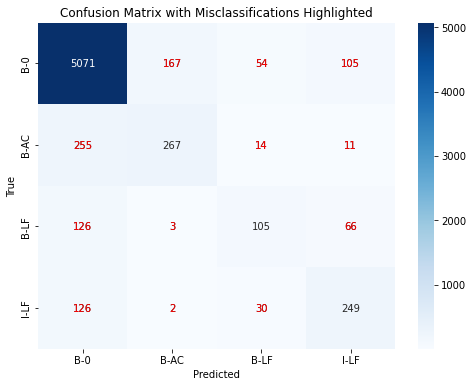

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Evaluate the model
def evaluate_model_confusion_matrix(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels in data_loader:
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=2)
            mask = labels != -100
            preds = preds[mask]
            labels = labels[mask]

            all_preds.extend(preds.flatten().tolist())
            all_labels.extend(labels.flatten().tolist())

    return all_labels, all_preds

# Evaluate on test set
test_labels, test_preds = evaluate_model_confusion_matrix(model, test_loader)

# Calculate confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Define labels for confusion matrix
labels = ['B-0', 'B-AC', 'B-LF', 'I-LF']  

# Plot confusion matrix with misclassifications highlighted
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=labels, yticklabels=labels)

# Highlight misclassifications
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            plt.text(j + 0.5, i + 0.5, cm[i, j], color='red', ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix with Misclassifications Highlighted')
plt.show()


Mispredicted: B-0 as B-AC - Count: 167
Mispredicted: B-0 as B-LF - Count: 54
Mispredicted: B-0 as I-LF - Count: 105
Mispredicted: B-AC as B-0 - Count: 255
Mispredicted: B-AC as B-LF - Count: 14
Mispredicted: B-AC as I-LF - Count: 11
Mispredicted: B-LF as B-0 - Count: 126
Mispredicted: B-LF as B-AC - Count: 3
Mispredicted: B-LF as I-LF - Count: 66
Mispredicted: I-LF as B-0 - Count: 126
Mispredicted: I-LF as B-AC - Count: 2
Mispredicted: I-LF as B-LF - Count: 30


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

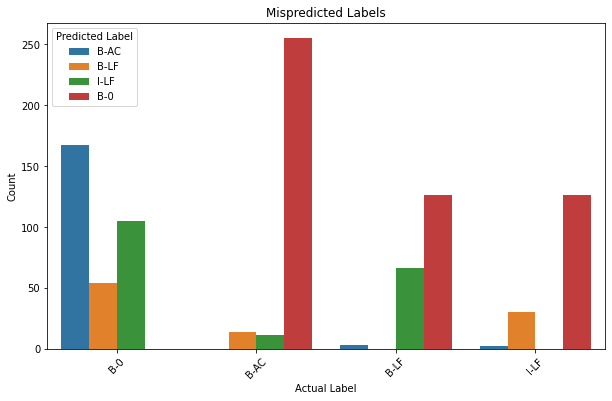

In [133]:
import pandas as pd

def get_mispredicted_pairs(confusion_matrix, labels):
    mispredicted_pairs = []

    for i in range(len(labels)):
        for j in range(len(labels)):
            if i != j and confusion_matrix[i, j] > 0:
                mispredicted_pairs.append((labels[i], labels[j], confusion_matrix[i, j]))

    return mispredicted_pairs

mispredicted_pairs = get_mispredicted_pairs(cm, labels)
for pair in mispredicted_pairs:
    print(f"Mispredicted: {pair[0]} as {pair[1]} - Count: {pair[2]}")


# Convert mispredicted pairs to DataFrame
mispredicted_df = pd.DataFrame(mispredicted_pairs, columns=['Actual', 'Predicted', 'Count'])

# Plot mispredicted pairs
plt.figure(figsize=(10, 6))
sns.barplot(x='Actual', y='Count', hue='Predicted', data=mispredicted_df)
plt.title('Mispredicted Labels')
plt.xlabel('Actual Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Predicted Label')
plt.show()


In [134]:
print('Notebook executed successfully')

Notebook executed successfully
